# EDA Quickstart

This notebook is a starter template for exploring `data/train.csv`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [2]:
train = pd.read_csv("../../data/train.csv")
test = pd.read_csv("../../data/test.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()

train shape: (577347, 12)
test shape: (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
# Basic structure
display(train.info())
display(train.describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,577347.0,NaN,NaN,NaN,288673.0,166665.86727,0.0,144336.5,288673.0,433009.5,577346.0
alpha,577347.0,NaN,NaN,NaN,181.616673,96.242941,0.011684,132.161499,188.681465,231.829693,359.99981
delta,577347.0,NaN,NaN,NaN,21.834654,18.93357,-17.966988,2.474097,21.484412,36.98831,79.158322
u,577347.0,NaN,NaN,NaN,22.441926,2.018135,-0.139225,20.97709,22.570222,23.869103,28.253263
g,577347.0,NaN,NaN,NaN,21.007273,1.795426,13.535483,19.865005,21.46782,22.292715,27.620208
r,577347.0,NaN,NaN,NaN,19.962811,1.648964,12.579407,18.820671,20.431153,21.164096,25.254499
i,577347.0,NaN,NaN,NaN,19.378911,1.580059,11.962781,18.30682,19.631642,20.608191,27.910853
z,577347.0,NaN,NaN,NaN,19.041136,1.584365,11.682803,17.973192,19.188598,20.162111,26.826867
redshift,577347.0,NaN,NaN,NaN,0.723135,0.81007,-0.00997,0.181052,0.497525,0.88139,7.01078
spectral_type,577347,4,M,303323,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Missing values
missing = train.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
display(missing.to_frame("missing_count"))

if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.head(30).plot(kind="bar")
    plt.title("Top missing columns")
    plt.tight_layout()
    plt.show()

,missing_count


In [5]:
# Target distribution
target_col = "class"
train[target_col].value_counts(dropna=False).to_frame("count")

,count
class,
GALAXY,377480
QSO,117143
STAR,82724


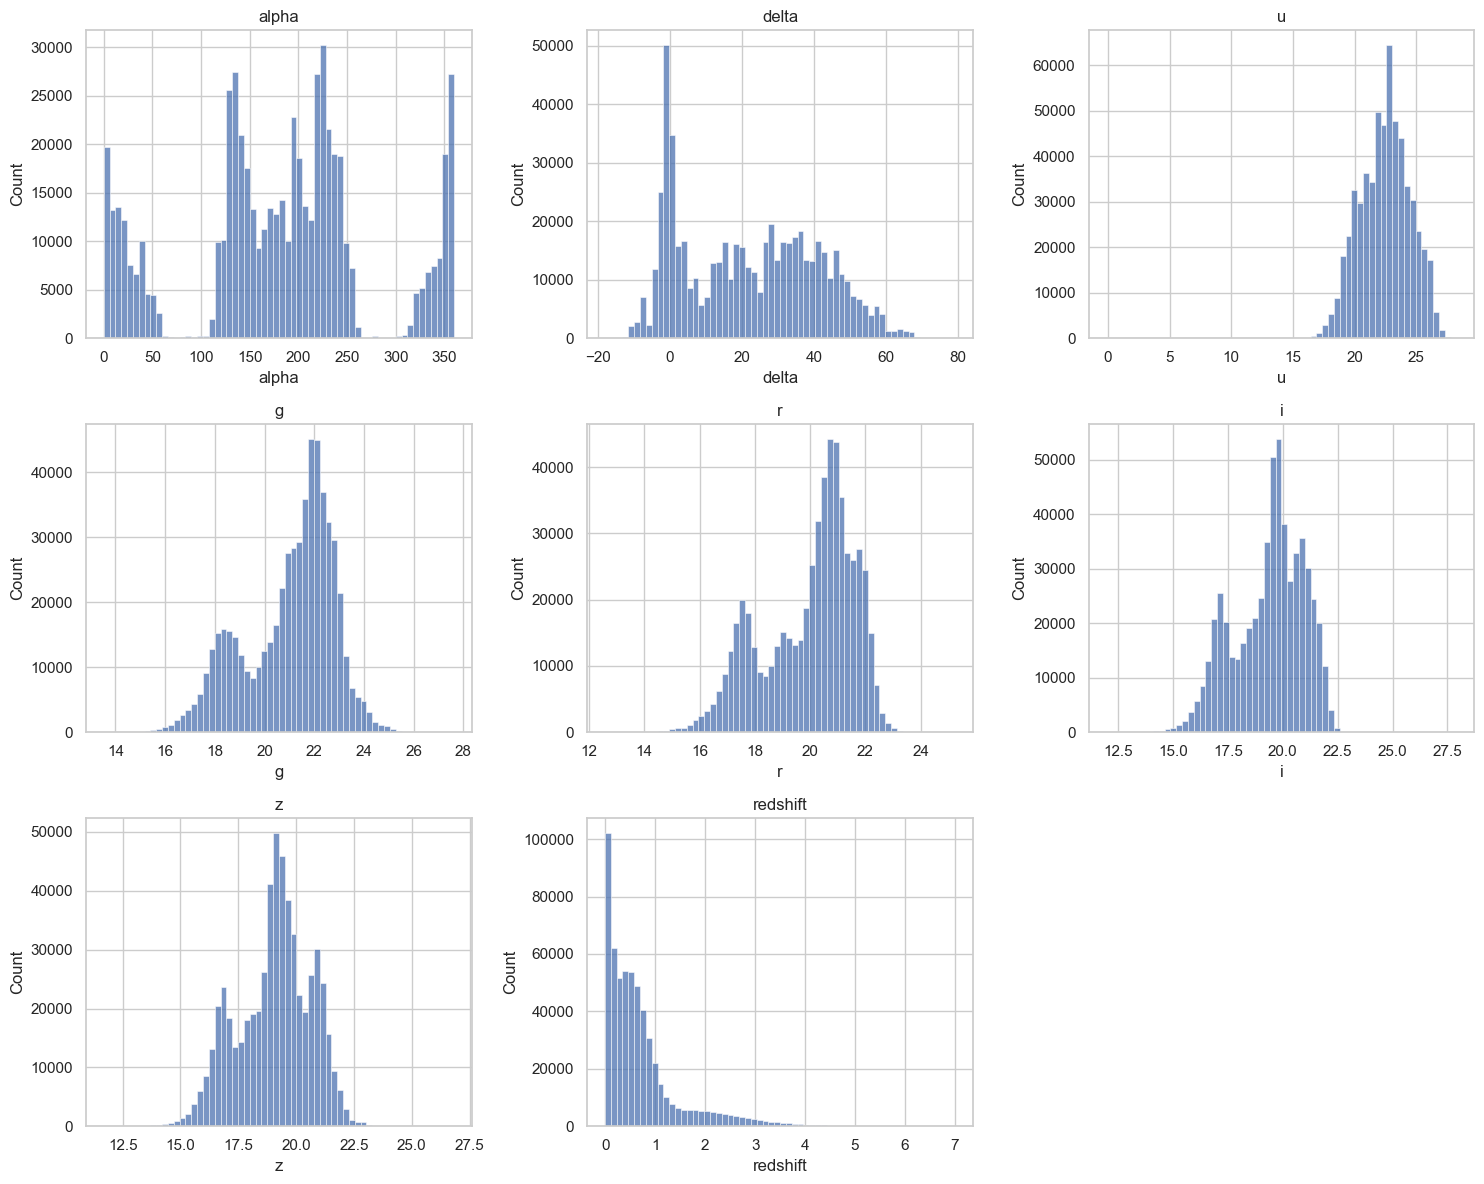

In [6]:
# Numeric feature distributions
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if "id" in num_cols:
    num_cols.remove("id")

sample_cols = num_cols[:12]
n = len(sample_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(sample_cols):
    sns.histplot(train[col], bins=60, kde=False, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

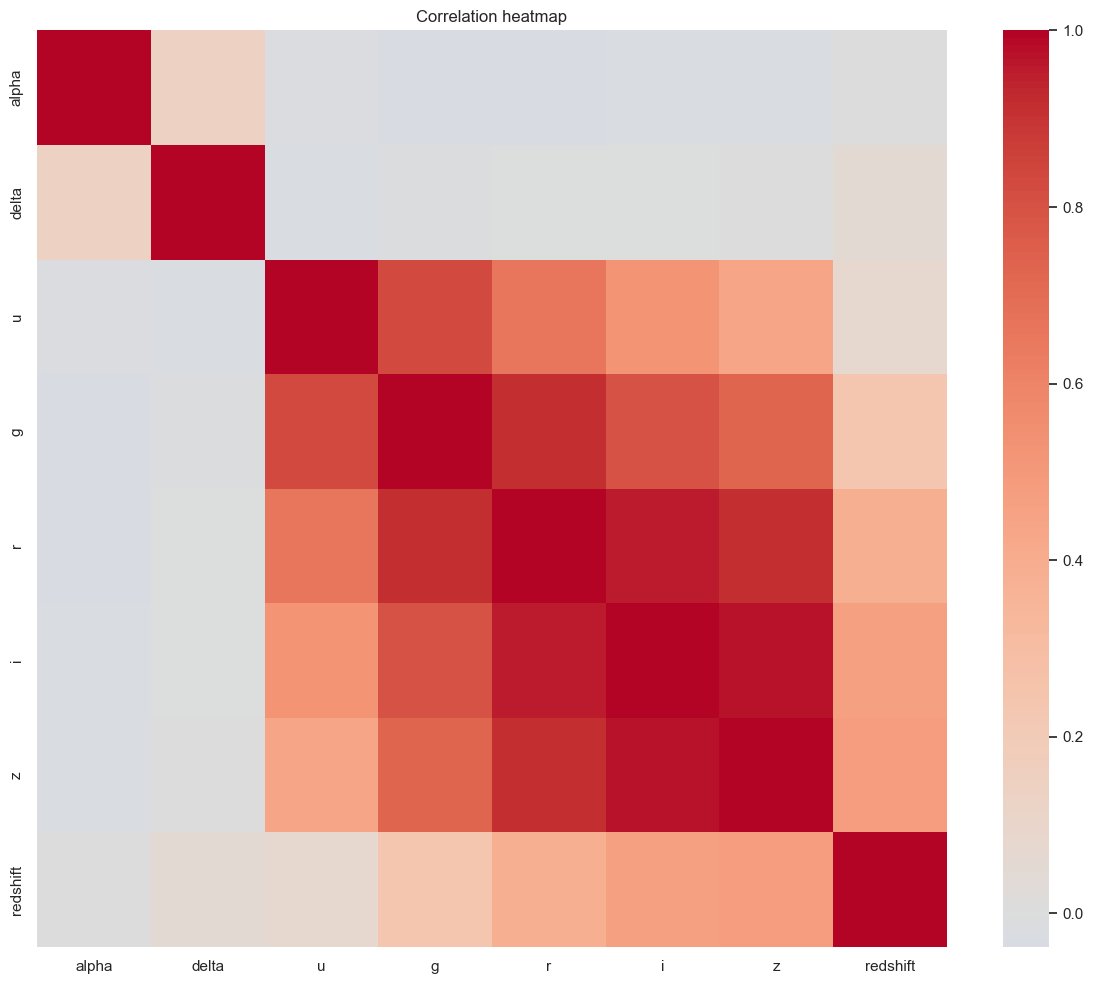

In [7]:
# Correlation heatmap (numeric only)
corr = train[num_cols].corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## Class-wise redshift analysis (all labels)

`GALAXY`, `QSO`, `STAR` の各ラベルについて、
- クラス分布
- `log1p(redshift)` の比較
- `redshift` の記述統計
をまとめて確認する。

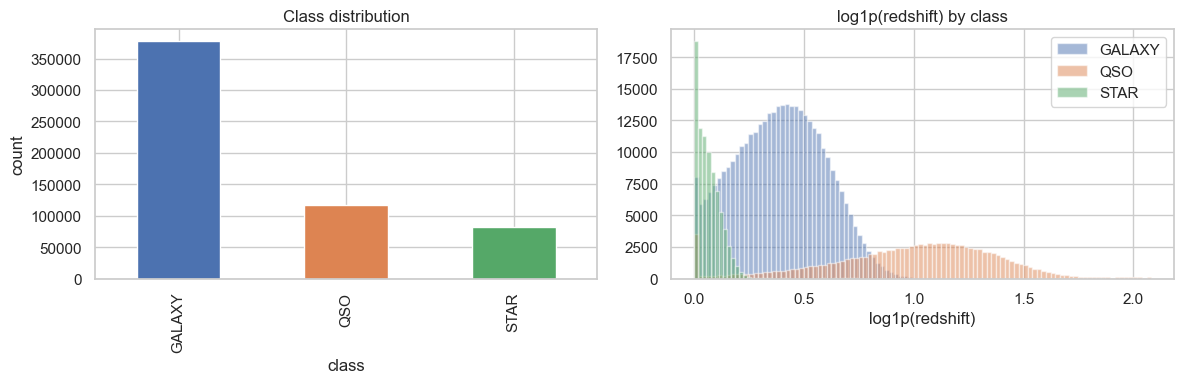

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,0.509026,0.309139,-0.009934,0.267017,0.481960,0.715023,6.860273
QSO,117143.0,1.875641,1.069731,0.000100,1.131805,1.798886,2.506401,7.010780
STAR,82724.0,0.068115,0.064476,-0.009970,0.021884,0.056492,0.102069,5.445217


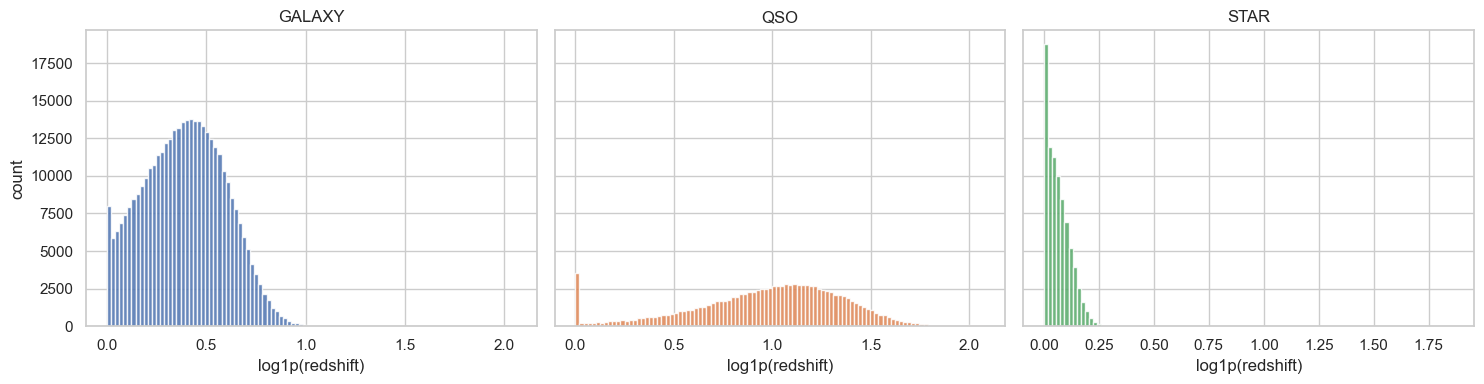

In [8]:
label_order = ["GALAXY", "QSO", "STAR"]
label_colors = ["#4c72b0", "#dd8452", "#55a868"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
train["class"].value_counts().reindex(label_order).plot.bar(
    ax=axes[0], color=label_colors
)
axes[0].set_title("Class distribution")
axes[0].set_ylabel("count")

# log1p(redshift) by class
for cls, color in zip(label_order, label_colors):
    subset = train.loc[train["class"] == cls, "redshift"]
    axes[1].hist(np.log1p(subset.clip(lower=0)), bins=100, alpha=0.5, label=cls, color=color)

axes[1].set_title("log1p(redshift) by class")
axes[1].set_xlabel("log1p(redshift)")
axes[1].legend()

plt.tight_layout()
plt.show()

display(train.groupby("class")["redshift"].describe().reindex(label_order))

# Optional: one subplot per label for easier shape comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cls, color in zip(axes, label_order, label_colors):
    subset = train.loc[train["class"] == cls, "redshift"]
    ax.hist(np.log1p(subset.clip(lower=0)), bins=100, color=color, alpha=0.85)
    ax.set_title(cls)
    ax.set_xlabel("log1p(redshift)")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

## Class-wise analysis for non-redshift features

`redshift` 以外の数値特徴量についても、ラベル（`GALAXY` / `QSO` / `STAR`）別に分布を比較する。

analyzing columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z']

=== alpha ===


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,178.557241,91.830843,0.022966,133.354583,191.988145,228.261924,359.999620
QSO,117143.0,189.665998,103.471298,0.011684,131.955763,186.151513,240.496107,359.999656
STAR,82724.0,184.178832,104.231295,0.022966,119.933598,188.068693,249.697908,359.999810



=== delta ===


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,21.033443,18.480962,-17.082120,2.824963,20.014815,35.591276,69.823814
QSO,117143.0,25.811829,19.583016,-17.798509,3.291282,29.278918,42.082580,69.262874
STAR,82724.0,19.858725,19.264123,-17.966988,0.827128,19.566963,36.233584,79.158322



=== u ===


...

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,19.860511,1.690032,12.579407,18.518337,20.329629,21.067438,25.132077
QSO,117143.0,20.918809,0.794862,14.922156,20.465681,21.013032,21.507116,25.054621
STAR,82724.0,19.075853,1.708943,13.175901,17.709279,19.034326,20.572070,25.254499



=== i ===


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,19.068222,1.499662,11.962781,17.927978,19.399104,19.995540,27.910853
QSO,117143.0,20.767309,0.792321,14.641368,20.308369,20.868987,21.325348,24.956405
STAR,82724.0,18.830555,1.673911,12.788387,17.513446,18.815990,20.235280,24.733455



=== z ===


,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
GALAXY,377480.0,18.629897,1.442609,11.682803,17.566337,18.928386,19.498330,26.826867
QSO,117143.0,20.602139,0.786691,14.502430,20.136703,20.697672,21.111851,24.015354
STAR,82724.0,18.707180,1.677109,12.620801,17.428904,18.695904,20.029342,25.042917


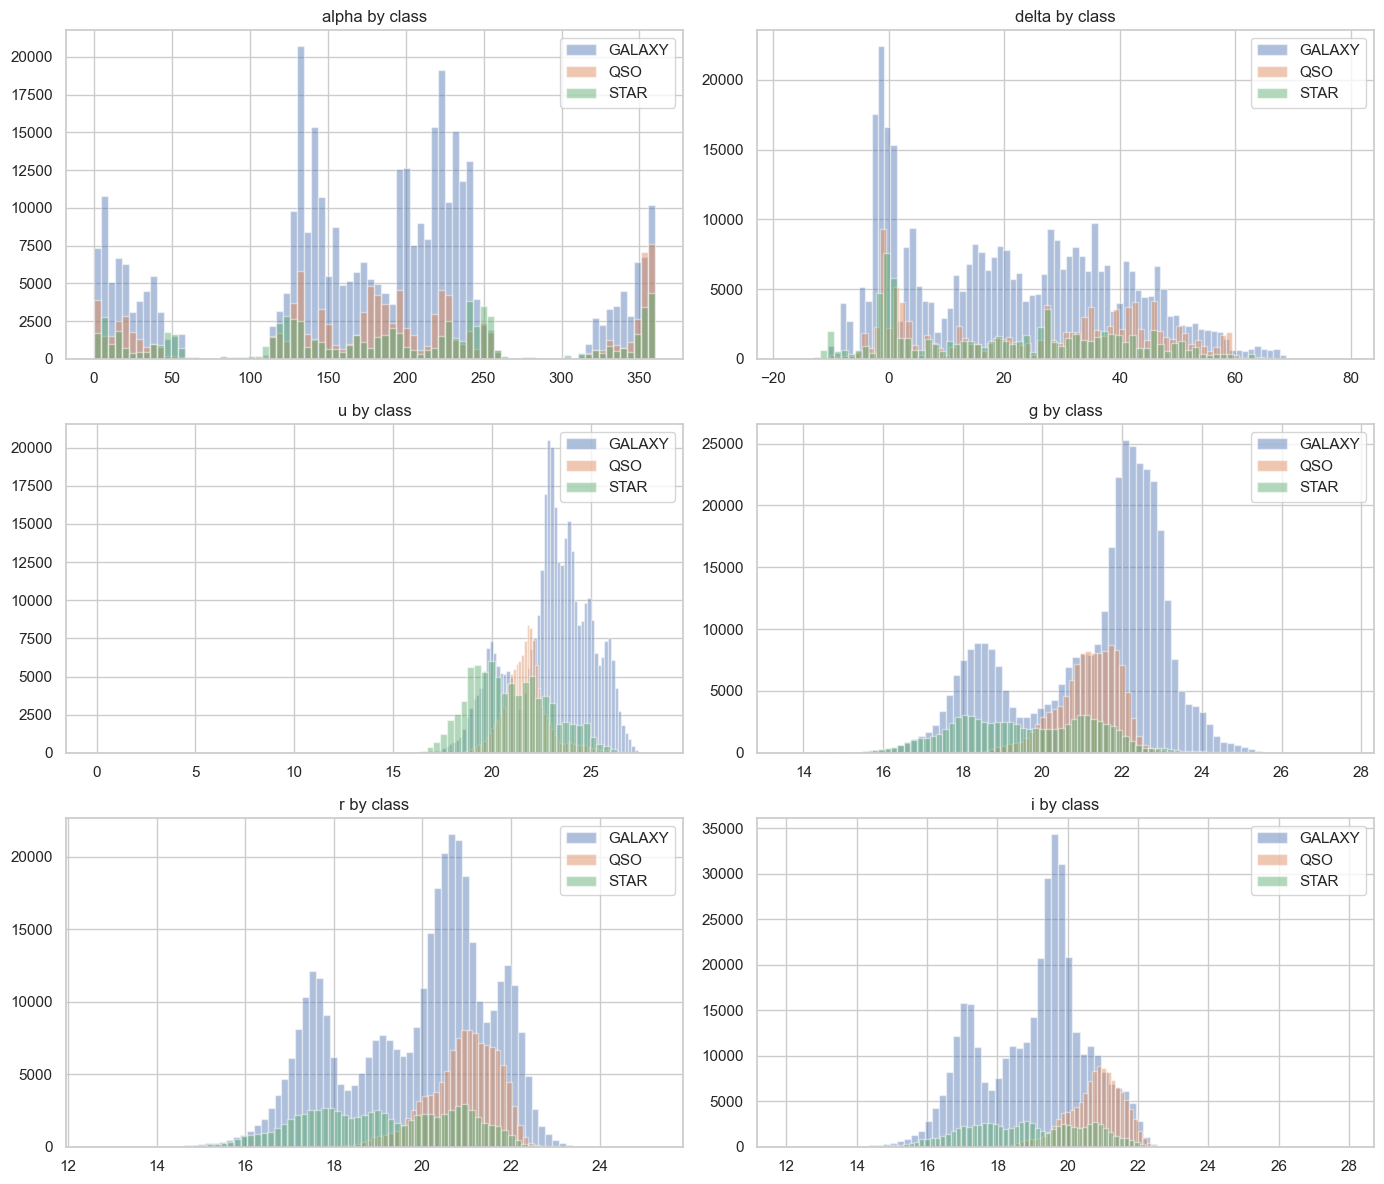

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


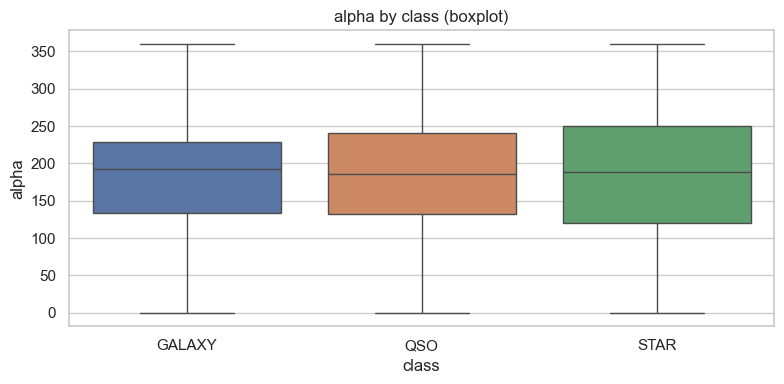

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


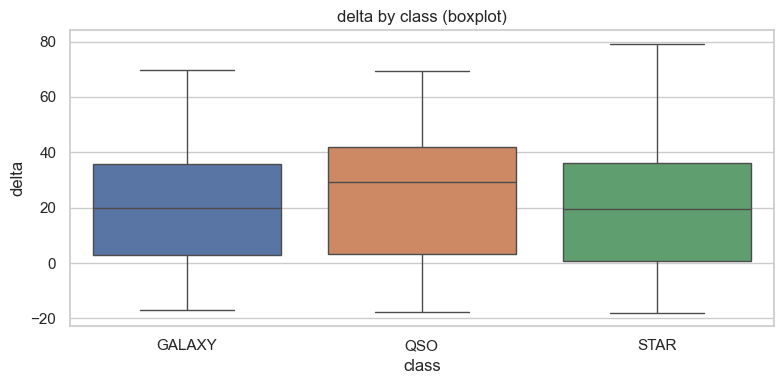

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


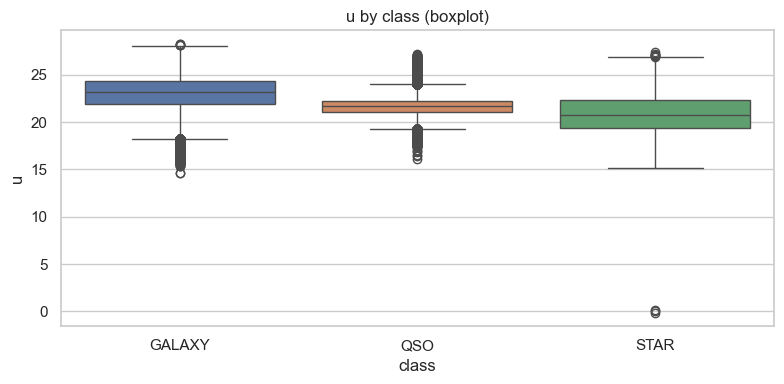

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


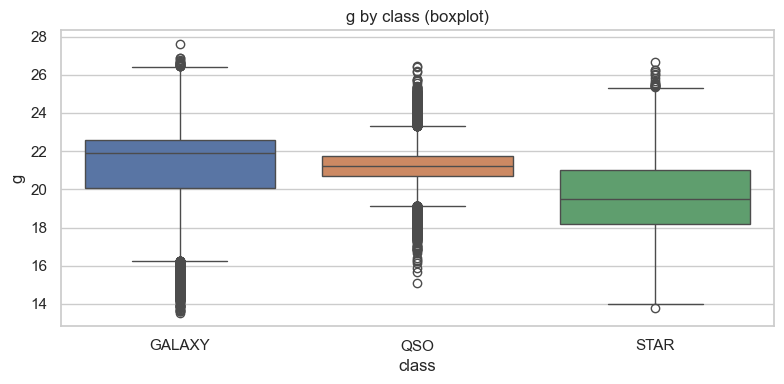

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


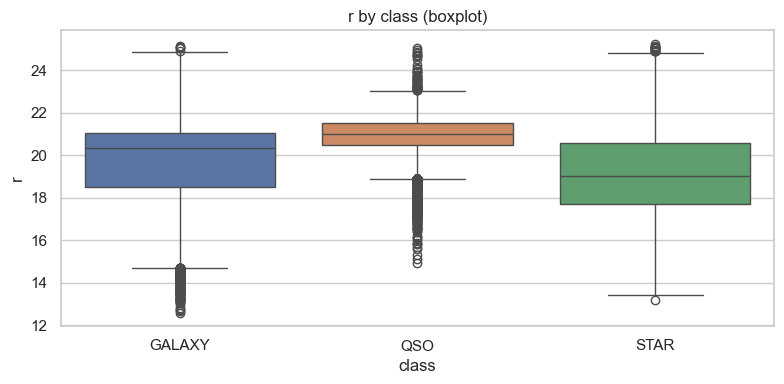

C:\Users\yusuke\AppData\Local\Temp\ipykernel_98672\3481791157.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)


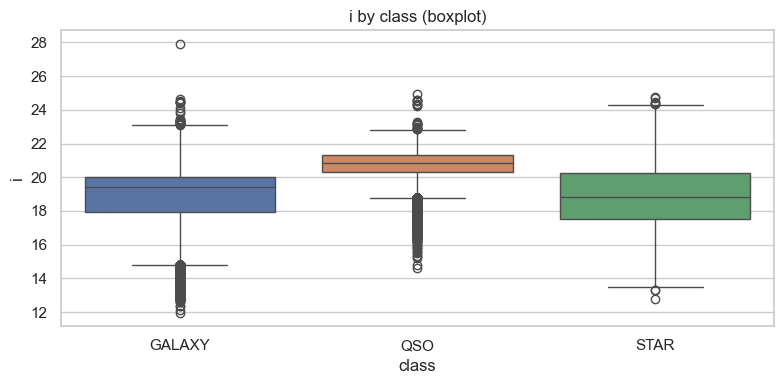

In [9]:
# redshift以外の数値列を対象にする
num_cols_no_redshift = [
    c for c in train.select_dtypes(include=[np.number]).columns
    if c not in ["id", "redshift"]
]

print("analyzing columns:", num_cols_no_redshift)

# 1) 各特徴量のクラス別記述統計
for col in num_cols_no_redshift:
    print(f"\n=== {col} ===")
    display(train.groupby("class")[col].describe().reindex(label_order))

# 2) 重ねヒストグラム（上位6列まで表示）
plot_cols = num_cols_no_redshift[:6]
if len(plot_cols) > 0:
    ncols = 2
    nrows = int(np.ceil(len(plot_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        for cls, color in zip(label_order, label_colors):
            subset = train.loc[train["class"] == cls, col].dropna()
            axes[i].hist(subset, bins=80, alpha=0.45, label=cls, color=color)
        axes[i].set_title(f"{col} by class")
        axes[i].legend()

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# 3) 箱ひげ図（分布差を見やすくする）
for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=train, x="class", y=col, order=label_order, palette=label_colors)
    plt.title(f"{col} by class (boxplot)")
    plt.tight_layout()
    plt.show()